## Requirements

In [1]:
"""

//#############################################################################
//  File:      MainOffshoreWave.py
//  Function:  Generates the plots for 'Testing Resilience Aspects of Operation 
//             Options for Offshore Wind Farms beyond the End-of-Life' by 
//             Corinna Köpke, Jennifer Mielniczek and Alexander Stolz 
//  Author:    Corinna Köpke
//  Date:      June-23
//  Copyright: (c) Fraunhofer Institute for High-Speed-Dynamics EMI
// https://www.mdpi.com/1996-1073/16/12/4771
//#############################################################################

"""

# Code reworked for educational purposes by Tobias Rinnert

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import seaborn as sns
import matplotlib as mpl
import warnings
import copy
warnings.filterwarnings('ignore')
# set jupyter notebook settings to ignore warnings



In [2]:
# jupyter notebook and plot options

# scale figure size with scale > 1 to reduce size. 1 = 16,9 fig size
fig_size_scale = 1.75 # for laptop screen

scale = fig_size_scale * 2
fs = 3 * 30 / scale # normal font size
fs_small = 2 * 30 / scale # small font size
pd.set_option('display.max_columns', None)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
params = {'legend.fontsize': fs_small,
          'legend.title_fontsize': fs_small,
          'figure.figsize': (16/fig_size_scale,9/fig_size_scale),
         'axes.labelsize': fs,
         'axes.titlesize':fs,
         "figure.titlesize": fs,
         'xtick.labelsize':fs_small,
         'ytick.labelsize':fs_small,
         'figure.autolayout': True}
plt.rcParams.update(params)
plt.rc('text', usetex=True)

## Functions

In [ ]:
def calc_max_wave_height(hsig, year_delta, maxH):
    """
    Calculate the maximum wave height for each month based on Rayleigh distribution scales.

    Args
    ----
    hsig:       Significant wave height \n
    year_delta: Difference in years from the base year \n
    maxH:       Maximum wave height to consider
    
    Returns
    --------
    float
                maximum wave height
    """

    # draw from a rayleigh distribution to get the significant wave height and from a uniform distribution to get the maximum wave height
    plus = np.random.uniform(low=0, high=hsig*(0.07*year_delta+3)) # see paper equation 2
    # the extra wave height cannot exceed the maximum wave height
    plus = min(plus, maxH)
    # the maximum wave height is the wave height plus the extra wave height
    hmax = hsig+abs(plus)
    return hmax

In [ ]:
def calc_frequ_wave_height(x,sigma, loadChanges_per_month):
    '''
    Rayleigh distribution function see paper equation 1

    Args
    ---
    x:                      wave height \n
    sigma:                  scale parameter \n
    loadChanges_per_month:  number of load changes per month\n

    Returns
    ---
    int
                            frequency of wave height x
    '''
    f = (x/sigma**2)*np.exp(-(x**2)/(2*sigma**2)) * loadChanges_per_month
    return int(max(f, 1))

In [ ]:
def WaveHeightFailure(minH,relH,number_load_changes):
    """
    Calculate the wave height that the structure can maximally handle given a specific number of load changes i.e. number of waves. 
    Equation 3 in the paper.
    
    See:    DIN EN 1993-1-9:2005 + AC:2009; Eurocode 3: 
            Design of steel structures—Part 1–9: Fatigue. 
            Deutsches Institut für Normung e.V. 
            German Institute for Standardization: 
            Berlin, Germany, 2009; German version EN.

    Args
    ---
    minH:                   minimum wave height for failure \n
    relH:                   maximum wave height for failure \n
    number_load_changes:    change in load \n
    
    Returns
    ---
    float
                            wave height
    """
    if number_load_changes == 0:
        return 10000 

    res = max(-0.5*np.log(number_load_changes)+relH, minH)
    return res

In [ ]:
def plotCumSum(WTlist, date_list, tdeg, eol, minC, maxC):
    """
    Plot the cumulative sum of load changes over time for multiple simulations.

    Args
    ---
    WTlist:     DataFrame containing cumulative load changes for each wave height and month \n
    date_list:  List of months \n
    tdeg:       Date of probable failure reaching 50% \n
    eol:        End of life date \n
    minC:       Minimum value for color mapping \n
    maxC:       Maximum value for color mapping
    """
    fig, ax = plt.subplots()
    
    # Plot vertical lines for probable failure reaching 0.5 and end of life
    ax.vlines(tdeg, ymin=0, ymax=WTlist.max().max(), color='k', label='prob. failure of 50\%')
    ax.vlines(eol, ymin=0, ymax=WTlist.max().max(), color='k', linestyle=':', label='End of Life')
    
    # Plot the load changes for each wave height over time on a semilogarithmic scale 
    cmap = plt.get_cmap('viridis', WTlist.shape[1]) # color map
    for i,x in enumerate(WTlist.T.values.tolist()):
        plt.semilogy(date_list, x, color=cmap(i)) 
    # create a colorbar to indicate wave heights
    norm = mpl.colors.Normalize(vmin=minC, vmax=maxC)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cb = plt.colorbar(sm, ticks=np.linspace(minC, maxC, WTlist.shape[1]), ax = ax)
    cb.ax.tick_params()

    # labeling the plot
    ax.set_xlabel('Time')
    ax.set_ylabel('Cumulative sum of \n load changes')
    ax.legend()

In [ ]:
def include_repair_time(x:pd.Series, nummonths) -> pd.Series:
    """
    Fill in repair times in a time series indicating broken (0) and working (1) states.
    After a unit is broken, it remains broken for 2 months before being repaired.

    Args
    ---
    x:          pd.Series with indices where the unit is broken (0) \n
    nummonths:  Total number of months in the time series \n

    Returns
    ---
    pd.Series 
                indicating working (1) and broken (0) states with repair times included
    """
    index = x[x == 0].index.tolist() # get the indices where the unit is broken
    broken_bool = pd.Series(np.ones(nummonths)) # initialize all as working
    repair_index = 0 # second index to avoid overlapping repairs
    for i in index:
        if i < repair_index:
            continue
        # 0 indicates broken, 1 indicates working. After 2 months the unit is repaired
        broken_bool.iloc[i:(i+3)] = [0,0,1][0:min(3,nummonths-i)]
        # repair + one working month so 3 months in total
        repair_index = i+3
    return broken_bool

## Set parameters

In [8]:
# choose EOL option
Mode = 'Decom' #'Decom', #'Exten', 'Repow'

# define teh start of the time period and the time of end of life
base = pd.Timestamp(2015,1,1)
eol = pd.Timestamp(2040,1,1) # end of life 

# generate a timestamp list of months
nummonths = 60*12 #60 years
date_list = pd.date_range(start=base, periods=nummonths, freq='MS').tolist()

severeWeatherSeasons = [1, 2, 3, 11, 12] #month with severe weather
loadChanges_per_month = 6*60*24*30 # load changes due to waves per month
rs1 = 1.5 # scale of a rayleigh distribution for severe weather
rs2 = 0.7 # scale of a rayleigh distribution for normal weather
Hmin = 8 #smallest wave height to consider
maxH = 40 #largest wave height to consider

minH_failure = 8
maxH_failure = 17
minHDe_failure = 10
maxHDe_failure = 19

# define the probability for a failure if the wave height is under or over the calculated wave height for failure
phigh = 0.5 # probability for failure if wave height is over the calculated wave height for failure
plow = 0.1 # probability for failure if wave height is under the calculated wave height for failure

# define the number of turbines per OSS and number of OSS
numTurbinesPerOSS = 60
numOSS = 3

# define teh minimal and maximal output of the wind turbines in MW for the Exten mode
minOut = 4 #MW
maxOut = 6 #MW Mittelwert bis 2022: 5.3MW, danach 9.5-15MW

# set seed for reproducibility
seed = 0


## Generate wave heights data and estimate the expected load

In [9]:
# create a dataframe to store the wave data
data_frame = pd.DataFrame(date_list, columns=['date'])

# create a list of booleans to indicate severe weather months
is_severe_month_mask = data_frame['date'].dt.month.isin(severeWeatherSeasons)

# set rs to rs1 for severe weather months and rs2 for normal months
data_frame.loc[is_severe_month_mask, 'rs'] = rs1
data_frame.loc[is_severe_month_mask == False, 'rs'] = rs2

# calculate the amount of severe weather months and normal months
amount_sever_months = is_severe_month_mask.sum()
amount_normal_months = nummonths - amount_sever_months

# generate significant wave heights from rayleigh distribution for severe and normal months
np.random.seed(seed) # set random seed for reproducibility
hsig_severe = np.random.rayleigh(scale=rs1, size=amount_sever_months) 
hsig_normal = np.random.rayleigh(scale=rs2, size=amount_normal_months)
data_frame.loc[is_severe_month_mask, 'Hsig'] = hsig_severe
data_frame.loc[is_severe_month_mask == False, 'Hsig'] = hsig_normal

# go through each row in the new dataframe
hmax_list, height_frequ_list, load_per_month, height_lists = [], [], [], [] # initialize lists to store calculated values

for index, row in data_frame.iterrows():

    # calcuate the maximum wave height in that month given the significant wave height and the year difference from the base year
    year_delta = row['date'].year - base.year
    hmax = calc_max_wave_height(row["Hsig"], year_delta, maxH, seed)

    if hmax > Hmin: # if there are wave heights to consider
        # calcualte the frequency of the wave heights in one month
        height_frequ = [calc_frequ_wave_height(h, row["rs"], loadChanges_per_month) for h in range(Hmin, int(hmax))] 
        
        # load per month is the number of waves impacting the structure per month
        load = sum(height_frequ)
    
    else:
        height_frequ = []
        load = 0

    # save the discrete wave heights
    height_lists.append(list(range(Hmin,int(hmax))))
    hmax_list.append(hmax)
    height_frequ_list.append(height_frequ)
    load_per_month.append(load)

# save the calculated values in the dataframe
data_frame["Hmax"] = hmax_list
data_frame["height_frequ_lists"] = height_frequ_list
data_frame["height_lists"] = height_lists
data_frame["load_per_month"] = load_per_month

# delete all lists now saved in the df to free memory
del date_list, hmax_list, height_frequ_list, height_lists, load_per_month

### Plot data

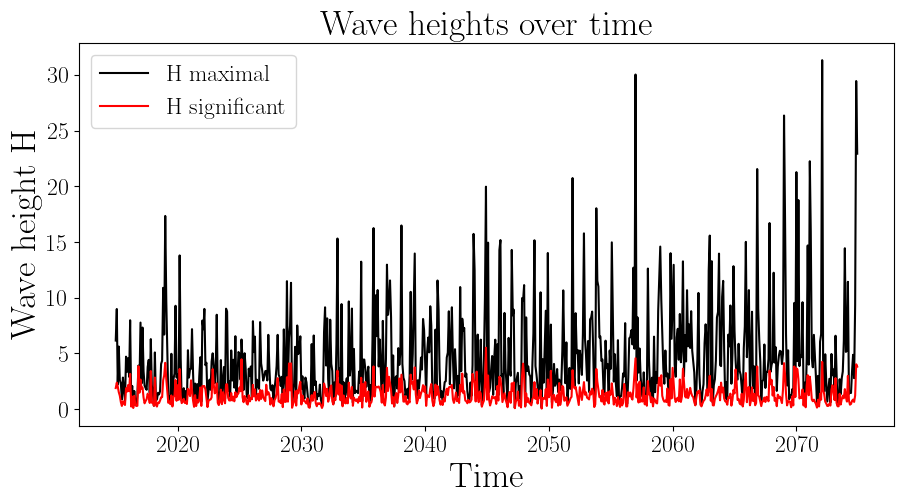

In [10]:
fig = plt.figure()
ax = fig.add_subplot()
plt.xticks()
plt.yticks()
plt.plot(data_frame["date"], data_frame["Hmax"], color='k',label='H maximal')
plt.plot(data_frame["date"], data_frame["Hsig"],color='red',label='H significant')
plt.xlabel('Time')
plt.ylabel('Wave height H')
plt.title('Wave heights over time')
plt.legend()

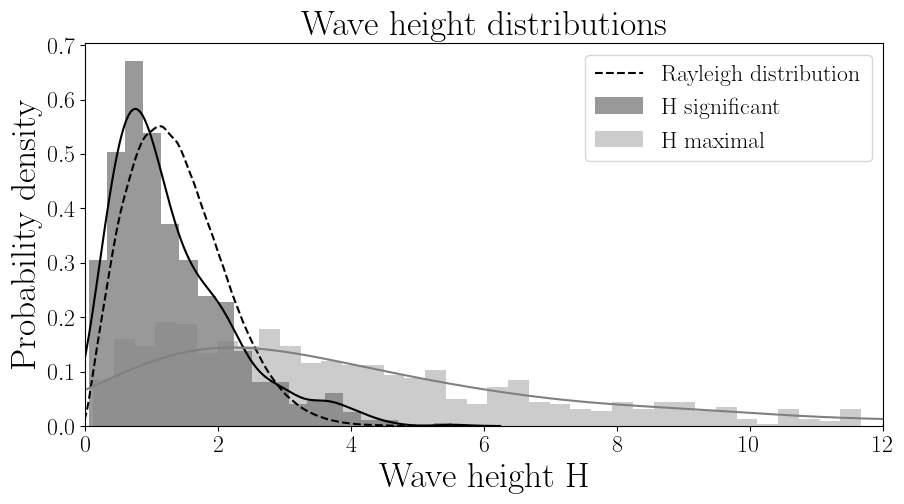

In [11]:
s = 1000000
ray_dist = np.random.rayleigh(scale=np.mean([rs1,rs2]), size=s)

fig, ax = plt.subplots()
ax.set_xlim(0, 12) 
plt.xticks()
plt.yticks()
sns.distplot(a=ray_dist, hist=False, color='k',kde_kws={'linestyle':'--'},label='Rayleigh distribution')
sns.distplot(a=data_frame["Hsig"], bins=20, hist=True, color='k',label='H significant')
sns.distplot(a=data_frame["Hmax"], bins=100, hist=True, color='grey',label='H maximal')
plt.xlabel('Wave height H')
plt.ylabel('Probability density')
plt.title('Wave height distributions')
plt.legend()

Text(0.5, 1.0, 'Load changes over time')

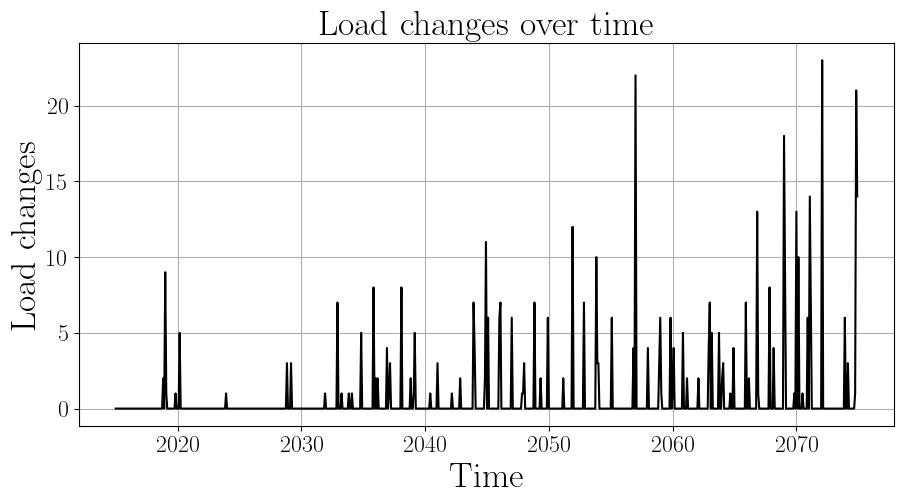

In [12]:
fig, ax = plt.subplots()
plt.plot(data_frame["date"], data_frame["load_per_month"], color='k',label='Load')
plt.xlabel('Time')
plt.ylabel('Load changes')
plt.grid()
plt.title('Load changes over time')

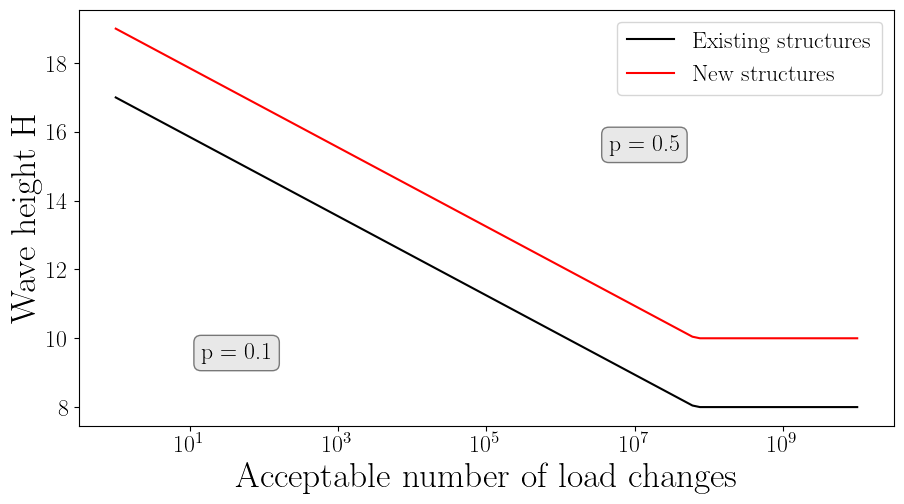

In [13]:
# plot number of load changes caused by a certin wave height that is still accaptable. 

# Calculate load failure
x = np.logspace(0,10,num=100,base=10)
y, yDe = [],[]
for i in x:
    y.append(WaveHeightFailure(minH_failure,maxH_failure,i)) # hrel https://www.fino1.de/de/standort/wellen-stroemung.html
    yDe.append(WaveHeightFailure(minHDe_failure,maxHDe_failure,i))

fig,ax = plt.subplots()
plt.xticks()
plt.yticks()
plt.semilogx(x, y, color='k',label='Existing structures') #semilogx
plt.semilogx(x, yDe, color='r',label='New structures') #semilogx
plt.xlabel('Acceptable number of load changes')
plt.ylabel('Wave height H')

# build a rectangle in axes coords
left, width = .15, .5
bottom, height = .15, .5
right = left + width
top = bottom + height
props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)
plt.text(right, top, 'p = 0.5', transform=ax.transAxes, verticalalignment='bottom', bbox=props, size=fs_small)
plt.text(left, bottom, 'p = 0.1', transform=ax.transAxes, verticalalignment='bottom', bbox=props, size=fs_small)

plt.legend()

## Calculate the Cumulative sum of load changes over time

In [14]:
# generate a dataframe. rows are months, columns are wave heights. For each month the frequency of the wave heights is saved
wave_list = []
for frequ, height in zip(data_frame["height_frequ_lists"].tolist(), data_frame["height_lists"].tolist()):
    base_array = np.array([0] * max(data_frame["height_frequ_lists"].apply(len)))
    if len(frequ) != 0:
        base_array[np.array(height) - Hmin] = frequ
    wave_list.append(base_array)
wave_df = pd.DataFrame(wave_list)
del wave_list # free memory

# cumulative sum over time for each wave height
WaveTimeCumSum = wave_df.cumsum(axis=0)

# cumulative sum over time for each wave height with decomissioning. 
decomDate = pd.Timestamp(2042,1,1) #date when decom is finished
Rebuild = pd.Timestamp(2050,1,1) # date when rebuilding is finished
WaveTimeCumSumDe = wave_df.copy()

# after decomission the structure does not accumulate any load changes. After rebuilding the structure starts accumulating load changes again from zero
WaveTimeCumSumDe.loc[(data_frame["date"] > decomDate) & (data_frame["date"] <= Rebuild)] = 0
WaveTimeCumSumDe = pd.concat([WaveTimeCumSumDe.loc[data_frame["date"] <= decomDate].cumsum(axis=0), 
                              WaveTimeCumSumDe.loc[data_frame["date"] > decomDate].cumsum(axis=0)])

# add the cumulative sums to the data frame. This is just done to view/understand the data better
data_frame["WaveTimeCumSum"] = WaveTimeCumSum.values.tolist()
data_frame["WaveTimeCumSumDe"] = WaveTimeCumSumDe.values.tolist()

In [15]:
# calculate at which waveheight the structure fails given the cumulative load changes of each discrete waveheight and for each month
wave_heights = data_frame["height_lists"].max() # get the list of possible wave heights
# calculate the prob of failure in each month for the existing structures
# The logic here had to be programmed somehow unintuitively so that the function referenced in WaveHeightFailure could be used.
# calculate how high a given wave can maximally be given 
# the frequency of the wave hitting the structure and min and maximum wave height the structure can endure
df_whf = WaveTimeCumSum.applymap(lambda x: WaveHeightFailure(minH_failure,maxH_failure,x)) 

# if for a given month, the wave height the structure can endure given the waves frequency 
# is smaller than the actual wave height with that frequency, the probability for failure goes up to 50%
df_whf_mask = (wave_heights > df_whf).any(axis=1) # get a list of booleans
data_frame["prop"] = [phigh if is_failure else plow for is_failure in df_whf_mask] 

# same for WaveTimeCumSumDe # TODO ask corinna: shouldnt the minHDe_failure and maxHDe_failure only be used after the structure is rebuild?
df_whf = WaveTimeCumSumDe.applymap(lambda x: WaveHeightFailure(minHDe_failure,maxHDe_failure,x)) 
df_whf_mask = (wave_heights > df_whf).any(axis=1)
data_frame["propDe"] =  [phigh if is_failure else plow for is_failure in df_whf_mask]

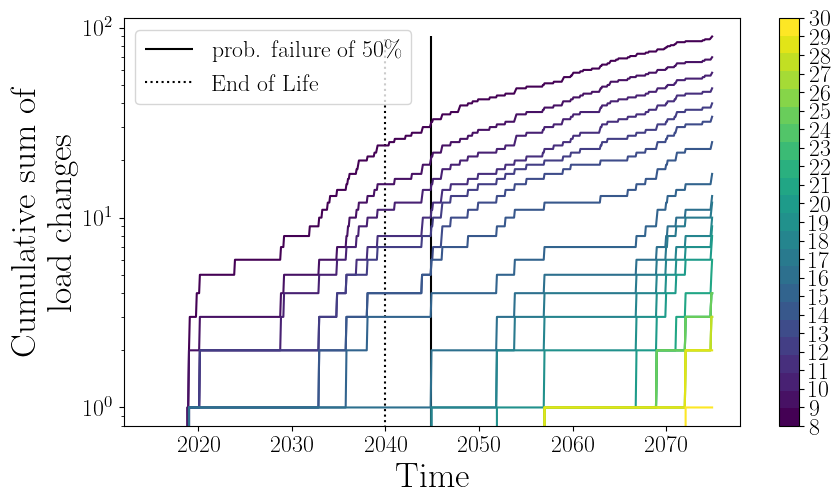

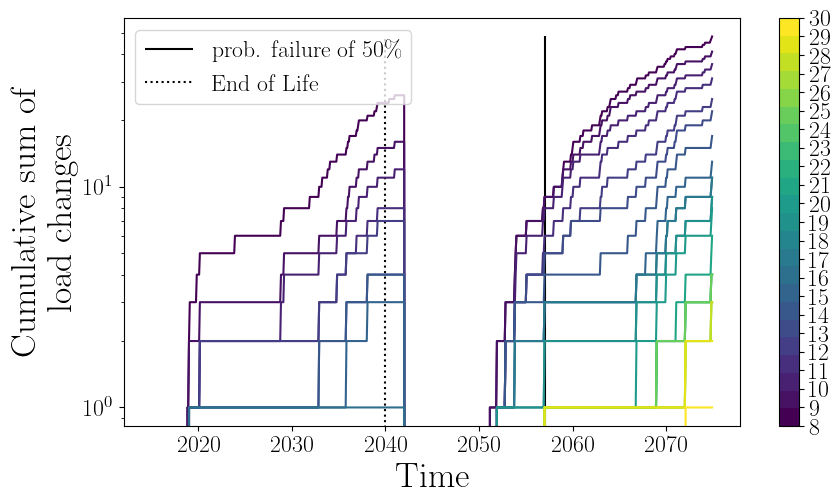

In [16]:
# plot the cumulative load changes for the existing structire and for the case that decomissioning and rebuilding is done

# get the month at which prob of failure reaches 50%
tdeg = data_frame[data_frame["prop"] == phigh]["date"].iloc[0]
tdegDe = data_frame[data_frame["propDe"] == phigh]["date"].iloc[0]

plotCumSum(WaveTimeCumSum, data_frame["date"], tdeg, eol, Hmin, max(wave_heights)) # structure stays in use
plotCumSum(WaveTimeCumSumDe, data_frame["date"], tdegDe, eol, Hmin, max(wave_heights)) # structure is decomissioned and rebuilt

## Create an offshore substation (OSS) network, destroy something and plot the performance

In [17]:
number_units = numOSS*numTurbinesPerOSS+numOSS # total number of turbines and OSS

df_waves_larger_15 = data_frame[data_frame["Hmax"] > 15] # only consider months with waves larger than 15m
broken_bool_df = np.random.uniform(0,1,size=df_waves_larger_15.shape[0] * number_units) # generate needed amount of random performance values 
broken_bool_df = pd.DataFrame(np.array(broken_bool_df).reshape(df_waves_larger_15.shape[0],number_units)) # reshape to needed shape  and convert to dataframe
broken_bool_df.set_index(df_waves_larger_15.index, inplace=True) # set the index to the months with waves larger than 15m

# the propability of failure depends on the mode #ask Corinna TODO
if Mode == 'Decom':
    propUse = pd.concat([data_frame["prop"][data_frame["date"] <= Rebuild], 
                         data_frame["propDe"][data_frame["date"] > Rebuild]]).values
else:
    propUse = data_frame["propDe"].values
  
propUse = propUse[data_frame["Hmax"] > 15] # only consider months with waves larger than 15m  

broken_bool_df = (broken_bool_df.T > propUse).T.astype(int) # 1 indicates working, 0 indicates broken

# repair time is 2 months after which teh unit works for at least one month. After that it can break again
# using apply here allows us to apply the function to each column. No need for for loops and we keep the dataframe structure
broken_bool_df = broken_bool_df.apply(lambda x: include_repair_time(x, nummonths), axis=0) 

In [18]:
Status = broken_bool_df.sum(axis=1) / number_units # status = ratio of working units

eout_df = broken_bool_df.copy() # create a copy to save the energy output
# for working units set a random energy output between minOut and maxOut
eout_df[broken_bool_df == 1] = np.random.uniform(minOut,maxOut,size=(broken_bool_df==1).sum().sum()).tolist() 

# for the modes Decom and Repow adjust the min and max energy output after the end of life / after rebuilding
if Mode in ["Decom", "Repow"]:
    eout_range = []
    for t in data_frame["date"][data_frame["date"] > eol]:
        if Mode == "Repow":
            minOut = min(minOut+0.05,6)
            maxOut = min(maxOut+0.05,9)
            eout_range.append((minOut, maxOut))
        else:
            if t <= Rebuild:
                minOut = max(minOut-0.15,0)
                maxOut = max(maxOut-0.15,0)
                eout_range.append((minOut, maxOut))
            if t > Rebuild:
                minOut = min(minOut+0.15,7)
                maxOut = min(maxOut+0.15,10)
                eout_range.append((minOut, maxOut))
    
    # generate the energy output as before but only for the first 60 turbines and after the end of life
    mode_df = pd.DataFrame([np.random.uniform(min,max,size=numTurbinesPerOSS) for min, max in eout_range])

    # get the index of the month after the end of life
    num_month_after_eol = data_frame["date"][data_frame["date"] > eol].index[0]

    # get a df of booleans where the units are broken after the end of life for the first 60 turbines
    mask = broken_bool_df.loc[num_month_after_eol:,:numTurbinesPerOSS - 1] == 0

    # where the units are broken set the energy output to 0
    mode_df[mask] = 0
    
    # overwrite the energy output after the end of life for the first 60 turbines with the new values
    eout_df.loc[num_month_after_eol:,:numTurbinesPerOSS - 1] = mode_df.values

    del mode_df, mask, eout_range # free memory

# calculate the total energy output per month
Energy = eout_df.sum(axis=1)

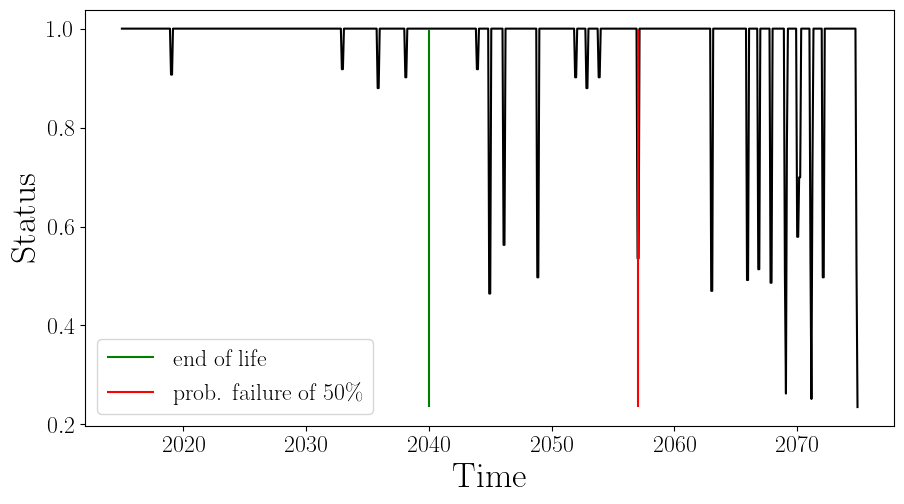

In [19]:
# set the date of the degernation depending on the mode
deg_date = tdegDe if Mode == 'Decom' else tdeg

# plot the status over time
fig, ax = plt.subplots()
plt.xticks()
plt.yticks()
plt.plot(data_frame["date"], Status, color='k') #semilogx
plt.vlines(eol, ymin=Status.min(), ymax=Status.max(), color='green', label='end of life')
plt.vlines(deg_date, ymin=Status.min(), ymax=Status.max(), color='red', label='prob. failure of 50\%')
plt.xlabel('Time')
plt.ylabel('Status')
plt.legend()

Area:  663542.6914846965


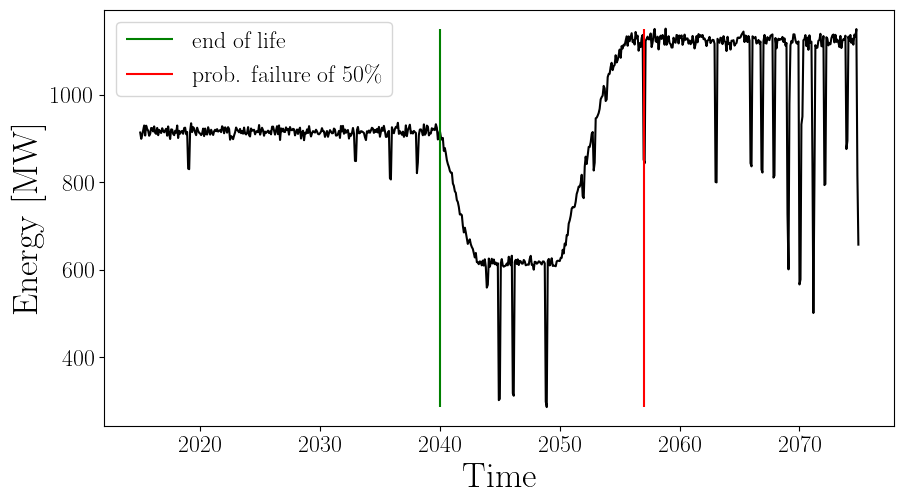

In [20]:
# plot the energy output over time

fig, ax = plt.subplots()
plt.xticks()
plt.yticks()
plt.plot(data_frame["date"], Energy, color='k') #semilogx
plt.vlines(eol, ymin=Energy.min(), ymax=Energy.max(), color='green', label='end of life')
plt.vlines(deg_date, ymin=Energy.min(), ymax=Energy.max(), color='red', label='prob. failure of 50\%')
plt.xlabel('Time')
plt.ylabel('Energy [MW]')
plt.legend()

# calculate the area under the energy curve
AreaE = np.trapz(Energy)
print('Area: ', AreaE)